# Additional Figures for Report/Presentation

This notebook generates supplementary visualizations:
1. Model comparison bar charts
2. SHAP analysis plots
3. Class imbalance visualization
4. Temporal train-test split illustration
5. Network graph visualization
6. GNN training curves
7. Case study examples

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# For SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP not installed. Run: pip install shap")
    SHAP_AVAILABLE = False

# For network visualization
try:
    import networkx as nx
    NX_AVAILABLE = True
except ImportError:
    print("NetworkX not installed. Run: pip install networkx")
    NX_AVAILABLE = False

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Plot settings
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "lines.linewidth": 1.5,
    "figure.dpi": 100
})

FIG_PATH = "../report/figures/"
SAVE_FIGS = True  # Set to True to save figures

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data and models
with open("../data/03-result/merged_df.pkl", "rb") as f:
    merged_df = pickle.load(f)
with open("../data/03-result/drugs_df.pkl", "rb") as f:
    drugs_df = pickle.load(f)
with open("../data/03-result/diseases_df.pkl", "rb") as f:
    diseases_df = pickle.load(f)
with open("../data/02-result/dates_df.pkl", "rb") as f:
    dates_df = pickle.load(f)

# Load trained models
with open("../results/models/time_split-models.pkl", "rb") as f:
    models = pickle.load(f)
with open("../results/models/time_split-summary_df.pkl", "rb") as f:
    summary_df = pickle.load(f)

print("Loaded models:", list(models.keys()))
print("\nSummary:")
display(summary_df)

Loaded models: ['knn', 'logreg', 'svm', 'rf', 'gb', 'xgb']

Summary:


,model,params,mean_test_score,std_test_score
0,knn,"{'knn__n_neighbors': 5, 'knn__p': 2, 'knn__wei...",0.581064,0.064035
1,logreg,"{'logreg__C': 0.1, 'logreg__l1_ratio': 0}",0.624640,0.030290
2,NaN,"{'logreg__C': 0.1, 'logreg__l1_ratio': 0.25}",0.624640,0.030290
3,NaN,"{'logreg__C': 0.1, 'logreg__l1_ratio': 0.5}",0.624640,0.030290
4,NaN,"{'logreg__C': 0.1, 'logreg__l1_ratio': 0.75}",0.624640,0.030290
5,NaN,"{'logreg__C': 0.1, 'logreg__l1_ratio': 1}",0.624640,0.030290
6,svm,"{'svm__C': 1, 'svm__degree': 2, 'svm__gamma': ...",0.619498,0.034367
7,NaN,"{'svm__C': 1, 'svm__degree': 2, 'svm__gamma': ...",0.619498,0.034367
8,rf,"{'rf__max_depth': 10, 'rf__min_samples_leaf': ...",0.592670,0.028305
9,gb,"{'gb__learning_rate': 0.05, 'gb__max_depth': 3...",0.611923,0.069881


In [3]:
# Prepare train/test split (same as in training notebook)
TRAIN_SIZE = 0.85

merged_df = (merged_df
    .merge(dates_df[["drug_id", "disease_id", "first_trial_date"]], 
           how="left", on=["drug_id", "disease_id"])
    .sort_values(by="first_trial_date")
    .reset_index(drop=True)
)

split_idx = int(merged_df.shape[0] * TRAIN_SIZE)
split_date = merged_df["first_trial_date"].iloc[split_idx]
print(f"Split date: {split_date}")
print(f"Train samples: {split_idx}, Test samples: {len(merged_df) - split_idx}")

# Prepare X and y
X = merged_df.drop(columns=["success", "drug_id", "disease_id", "drug_name", "disease_name", "first_trial_date"])
y = merged_df["success"]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Keep metadata for case studies
test_metadata = merged_df[["drug_id", "disease_id", "drug_name", "disease_name", "first_trial_date"]].iloc[split_idx:]

Split date: 2013-04
Train samples: 756, Test samples: 134


---
## 1. Model Comparison Bar Chart

In [4]:
# Compute test metrics for all models
full_names = {
    "knn": "k-NN",
    "logreg": "Logistic Reg.",
    "svm": "SVM",
    "rf": "Random Forest",
    "gb": "Gradient Boost",
    "xgb": "XGBoost"
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": full_names.get(name, name),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(3))

                   F1  Precision  Recall
Model                                   
k-NN            0.621      0.525   0.762
Logistic Reg.   0.596      0.500   0.738
SVM             0.641      0.541   0.786
Random Forest   0.657      0.821   0.548
Gradient Boost  0.658      0.774   0.571
XGBoost         0.625      0.658   0.595


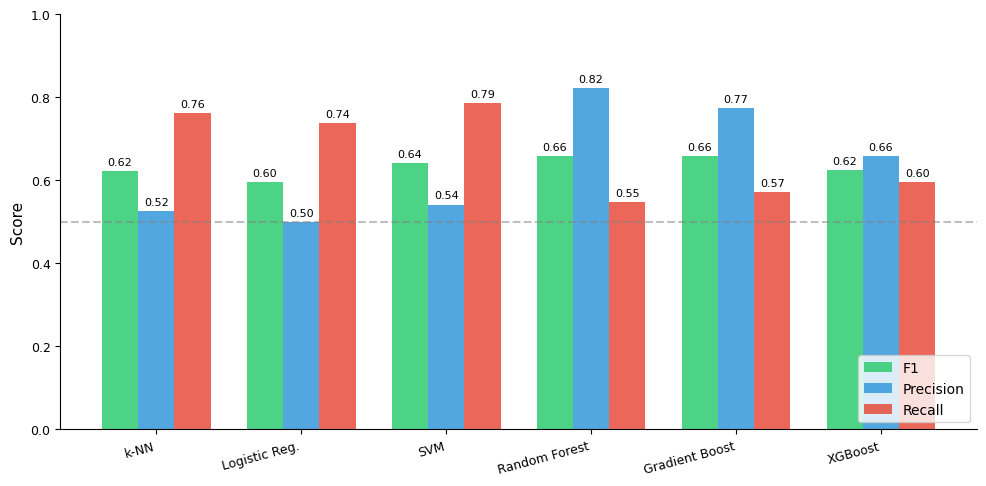

In [5]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.25

colors = ["#2ecc71", "#3498db", "#e74c3c"]
metrics = ["F1", "Precision", "Recall"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-model_comparison_bar.png", dpi=300, bbox_inches="tight")
plt.show()

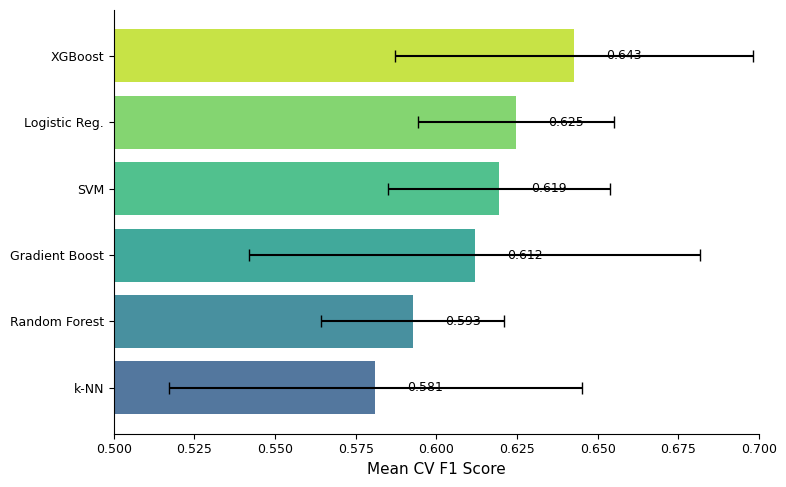

In [25]:
# Cross-validation F1 scores comparison (from training)
# Fix: Drop rows with NaN model names and keep only one row per model (best result)
cv_results = summary_df[["model", "mean_test_score", "std_test_score"]].copy()
cv_results = cv_results.dropna(subset=["model"])  # Remove rows with NaN model names
cv_results["model"] = cv_results["model"].map(full_names)
cv_results = cv_results.sort_values("mean_test_score", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(cv_results)))

bars = ax.barh(cv_results["model"], cv_results["mean_test_score"], 
               xerr=cv_results["std_test_score"], color=colors, alpha=0.85,
               capsize=4)

ax.set_xlabel("Mean CV F1 Score")
ax.set_xlim(0.5, 0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars, cv_results["mean_test_score"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-cv_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 2. Class Imbalance Visualization

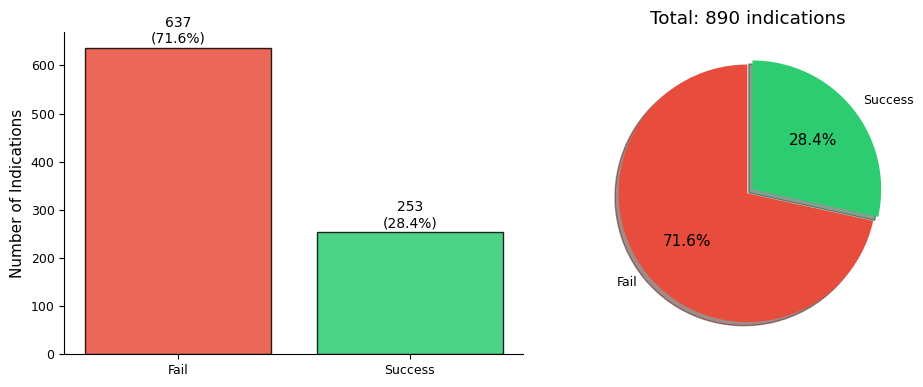

Class ratio (Fail:Success) = 2.52:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts = y.value_counts()
colors = ["#e74c3c", "#2ecc71"]
labels = ["Fail", "Success"]

ax = axes[0]
bars = ax.bar(labels, [counts[False], counts[True]], color=colors, alpha=0.85, edgecolor='black')
ax.set_ylabel("Number of Indications")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, count in zip(bars, [counts[False], counts[True]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{count}\n({count/len(y)*100:.1f}%)', ha='center', fontsize=10)

# Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie([counts[False], counts[True]], 
                                   labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   explode=(0, 0.05), shadow=True)
ax.set_title(f"Total: {len(y)} indications")

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-class_imbalance.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Class ratio (Fail:Success) = {counts[False]/counts[True]:.2f}:1")

---
## 3. Temporal Train-Test Split Illustration

/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_64372/3862182232.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  bins = pd.date_range(start='1990', end='2025', freq='Y')


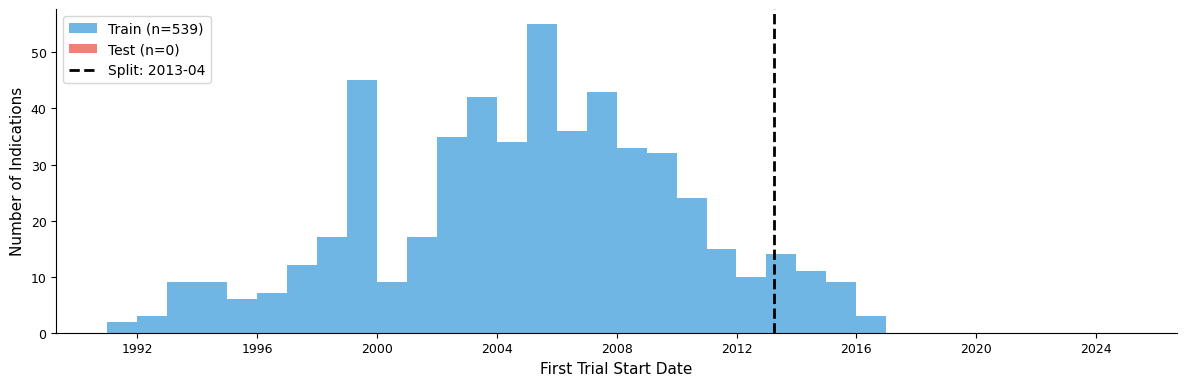

In [7]:
# Prepare date data
dates = pd.to_datetime(merged_df["first_trial_date"], errors='coerce')
dates_valid = dates.dropna()

fig, ax = plt.subplots(figsize=(12, 4))

# Histogram of trial start dates
train_dates = dates_valid.iloc[:split_idx]
test_dates = dates_valid.iloc[split_idx:]

bins = pd.date_range(start='1990', end='2025', freq='Y')

ax.hist(train_dates, bins=bins, alpha=0.7, label=f'Train (n={len(train_dates)})', color='#3498db')
ax.hist(test_dates, bins=bins, alpha=0.7, label=f'Test (n={len(test_dates)})', color='#e74c3c')

# Add vertical line at split
split_date_dt = pd.to_datetime(split_date)
ax.axvline(x=split_date_dt, color='black', linestyle='--', linewidth=2, label=f'Split: {split_date}')

ax.set_xlabel("First Trial Start Date")
ax.set_ylabel("Number of Indications")
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-temporal_split.png", dpi=300, bbox_inches="tight")
plt.show()

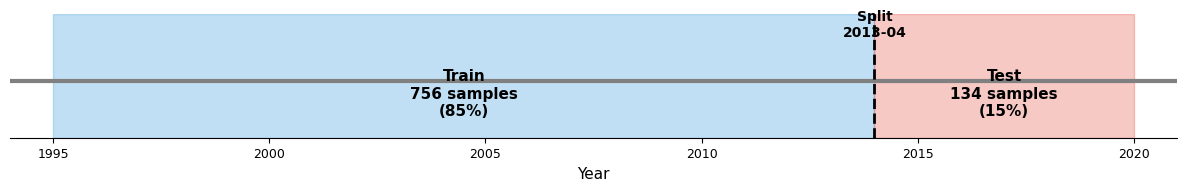

In [24]:
# Timeline diagram
fig, ax = plt.subplots(figsize=(12, 2))

# Draw timeline
ax.axhline(y=0.5, color='gray', linewidth=3)

# Get valid dates for train and test
train_dates_valid = train_dates.dropna()
test_dates_valid = test_dates.dropna()

# Handle case where dates might be empty or have issues
if len(train_dates_valid) > 0 and len(test_dates_valid) > 0:
    train_start = train_dates_valid.min().year
    train_end = pd.to_datetime(split_date).year if pd.notna(pd.to_datetime(split_date, errors='coerce')) else 2014
    test_end = test_dates_valid.max().year
else:
    # Fallback values if dates are problematic
    train_start = 1995
    train_end = 2014
    test_end = 2020

ax.axvspan(train_start, train_end, alpha=0.3, color='#3498db', label='Train')
ax.axvspan(train_end, test_end, alpha=0.3, color='#e74c3c', label='Test')

# Split line
ax.axvline(x=train_end, color='black', linestyle='--', linewidth=2)
ax.text(train_end, 0.9, f'Split\n{split_date}', ha='center', fontsize=10, fontweight='bold')

# Labels
ax.text((train_start + train_end)/2, 0.2, f'Train\n{split_idx} samples\n({split_idx/len(merged_df)*100:.0f}%)', 
        ha='center', fontsize=11, fontweight='bold')
ax.text((train_end + test_end)/2, 0.2, f'Test\n{len(merged_df)-split_idx} samples\n({(len(merged_df)-split_idx)/len(merged_df)*100:.0f}%)', 
        ha='center', fontsize=11, fontweight='bold')

ax.set_xlim(train_start - 1, test_end + 1)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Year")
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-temporal_split_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4. SHAP Analysis (XGBoost)

In [ ]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Get the XGBoost model and preprocessor
    xgb_pipeline = models['xgb']
    preprocessor = xgb_pipeline.named_steps['preprocess']
    xgb_model = xgb_pipeline.named_steps['xgb']
    
    # Transform the test data
    X_test_transformed = preprocessor.transform(X_test)
    
    # Get feature names after preprocessing - must match transformed data columns
    # The preprocessor transforms numeric columns, so we use the original column order
    num_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    
    # Feature names should match the number of columns in transformed data
    n_features = X_test_transformed.shape[1]
    if len(num_cols) == n_features:
        feature_names = num_cols
    else:
        # Fallback: use generic names if mismatch
        feature_names = [f"feature_{i}" for i in range(n_features)]
        # Try to identify key features by position
        if 'path_similarity' in num_cols:
            path_sim_idx = num_cols.index('path_similarity')
            if path_sim_idx < n_features:
                feature_names[path_sim_idx] = 'path_similarity'
        if 'nb_indications' in num_cols:
            nb_ind_idx = num_cols.index('nb_indications')
            if nb_ind_idx < n_features:
                feature_names[nb_ind_idx] = 'nb_indications'
    
    print(f"Number of features in X: {len(num_cols)}")
    print(f"Number of features after transform: {n_features}")
    print(f"Feature names length: {len(feature_names)}")
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_transformed)
    
    print(f"SHAP values shape: {shap_values.shape}")
else:
    print("SHAP not available or XGBoost model not found")

SHAP values shape: (134, 241)


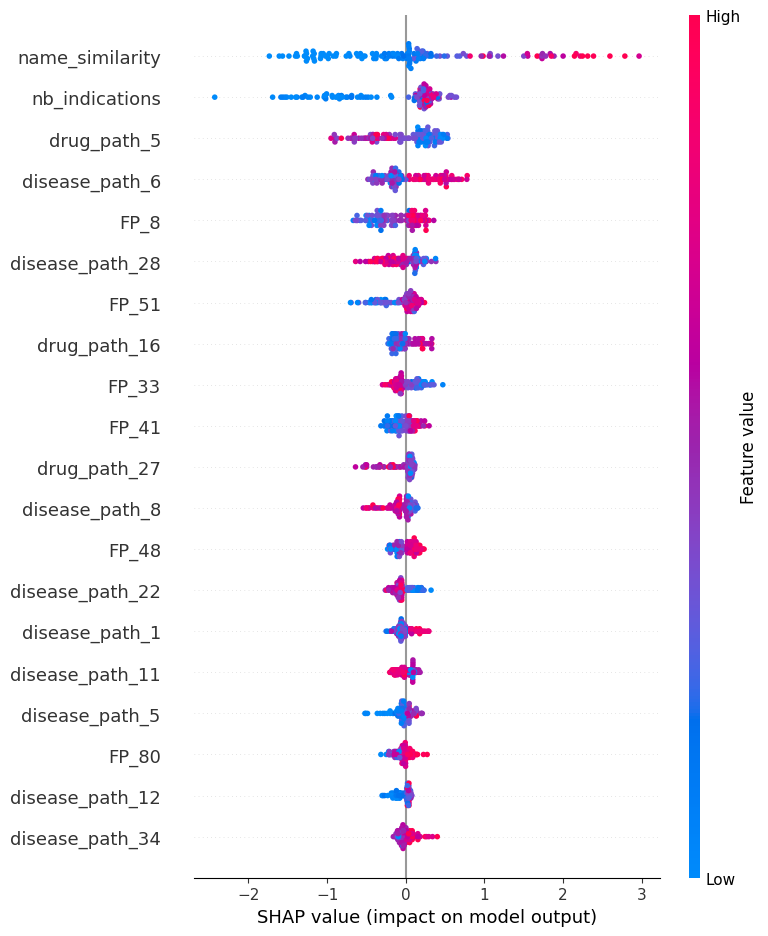

In [10]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Summary plot (beeswarm)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_transformed, 
                      feature_names=feature_names,
                      max_display=20, show=False)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

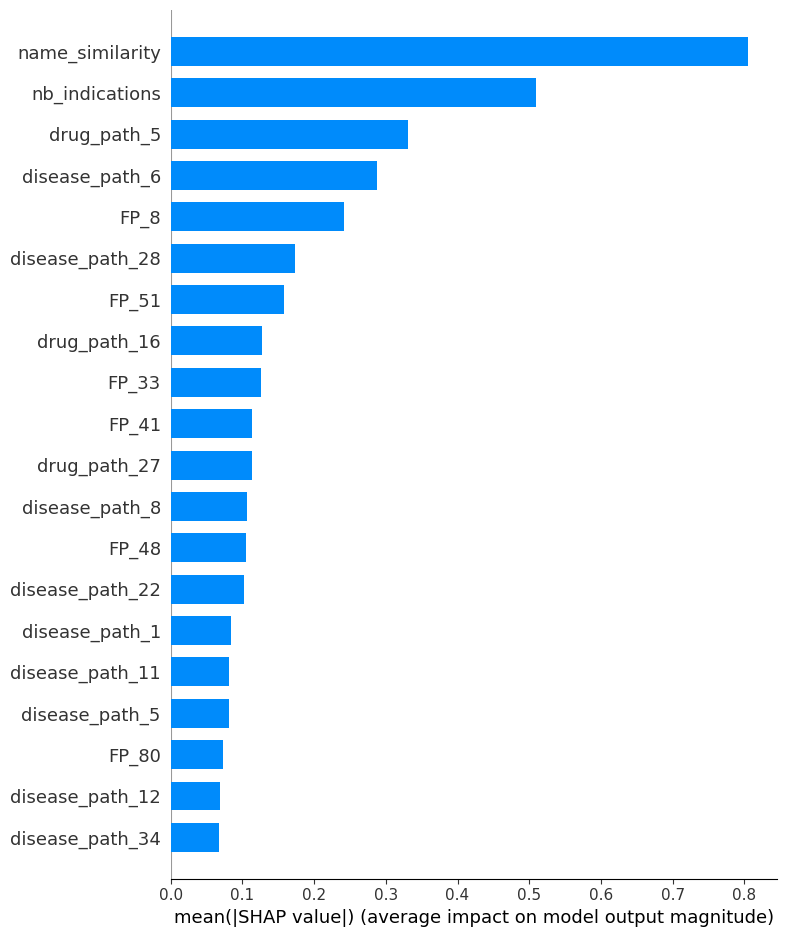

In [11]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Bar plot of mean absolute SHAP values
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed, 
                      feature_names=feature_names,
                      plot_type="bar", max_display=20, show=False)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_importance_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

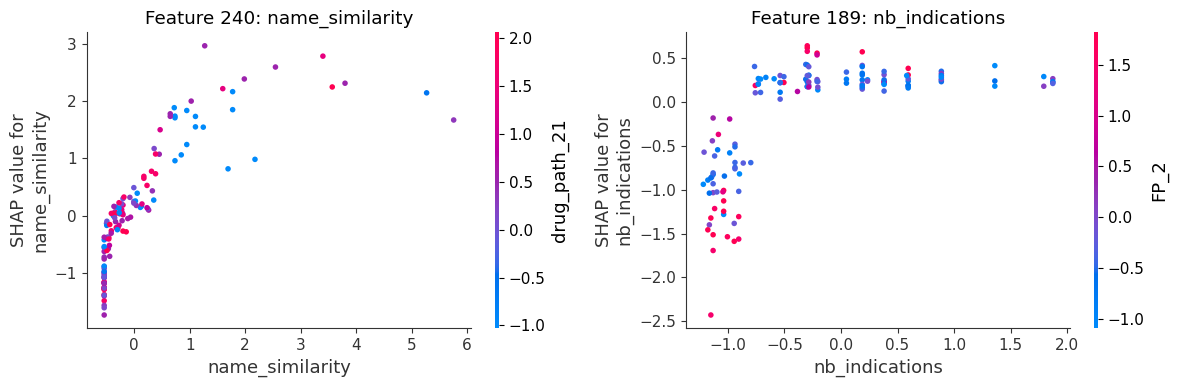

In [23]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Dependence plot for top features
    # Use column index directly from transformed data shape
    n_features = X_test_transformed.shape[1]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Find path_similarity index safely
    path_sim_idx = None
    nb_ind_idx = None
    
    if 'path_similarity' in feature_names:
        path_sim_idx = feature_names.index('path_similarity')
        if path_sim_idx >= n_features:
            path_sim_idx = None
    
    if 'nb_indications' in feature_names:
        nb_ind_idx = feature_names.index('nb_indications')
        if nb_ind_idx >= n_features:
            nb_ind_idx = None
    
    # If we couldn't find them, use the most important features from SHAP
    if path_sim_idx is None or nb_ind_idx is None:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        top_indices = np.argsort(mean_abs_shap)[::-1][:2]
        if path_sim_idx is None:
            path_sim_idx = top_indices[0]
        if nb_ind_idx is None:
            nb_ind_idx = top_indices[1] if len(top_indices) > 1 else top_indices[0]
    
    # Plot first feature
    shap.dependence_plot(path_sim_idx, shap_values, X_test_transformed,
                         feature_names=feature_names, ax=axes[0], show=False)
    axes[0].set_title(f"Feature {path_sim_idx}: {feature_names[path_sim_idx] if path_sim_idx < len(feature_names) else 'Top 1'}")
    
    # Plot second feature
    shap.dependence_plot(nb_ind_idx, shap_values, X_test_transformed,
                         feature_names=feature_names, ax=axes[1], show=False)
    axes[1].set_title(f"Feature {nb_ind_idx}: {feature_names[nb_ind_idx] if nb_ind_idx < len(feature_names) else 'Top 2'}")
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_dependence.png", dpi=300, bbox_inches="tight")
    plt.show()

---
## 5. Network Graph Visualization

In [13]:
if NX_AVAILABLE:
    # Create a small subgraph for visualization
    # Select a few drugs and diseases with connections
    
    # Sample some indications
    sample_size = 30
    sample_df = merged_df.sample(n=min(sample_size, len(merged_df)), random_state=42)
    
    G = nx.Graph()
    
    # Add drug nodes
    drugs_in_sample = sample_df["drug_name"].unique()
    for drug in drugs_in_sample:
        G.add_node(drug, node_type='drug')
    
    # Add disease nodes
    diseases_in_sample = sample_df["disease_name"].unique()
    for disease in diseases_in_sample:
        G.add_node(disease, node_type='disease')
    
    # Add edges (drug-disease indications)
    for _, row in sample_df.iterrows():
        G.add_edge(row["drug_name"], row["disease_name"], 
                   success=row["success"])
    
    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    print(f"  Drugs: {len(drugs_in_sample)}, Diseases: {len(diseases_in_sample)}")

Graph: 50 nodes, 30 edges
  Drugs: 30, Diseases: 20


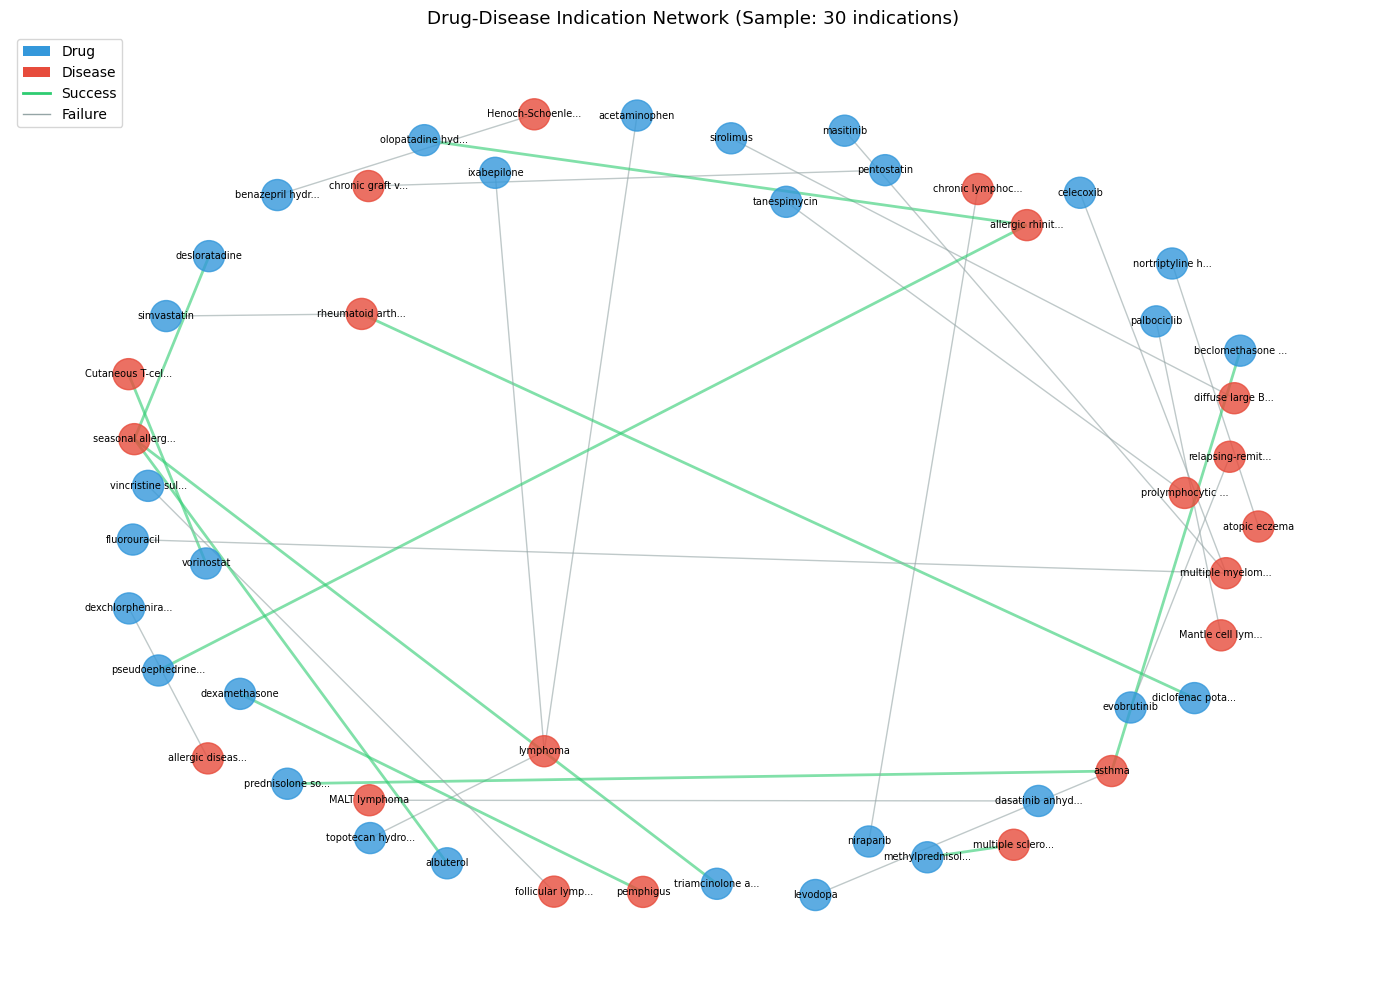

In [14]:
if NX_AVAILABLE:
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Node colors by type
    node_colors = ['#3498db' if G.nodes[n]['node_type'] == 'drug' else '#e74c3c' 
                   for n in G.nodes()]
    
    # Edge colors by success
    edge_colors = ['#2ecc71' if G.edges[e]['success'] else '#95a5a6' 
                   for e in G.edges()]
    edge_widths = [2 if G.edges[e]['success'] else 1 for e in G.edges()]
    
    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500, alpha=0.8, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6, ax=ax)
    
    # Labels with smaller font
    labels = {n: n[:15] + '...' if len(n) > 15 else n for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=7, ax=ax)
    
    # Legend
    legend_elements = [
        Patch(facecolor='#3498db', label='Drug'),
        Patch(facecolor='#e74c3c', label='Disease'),
        Line2D([0], [0], color='#2ecc71', linewidth=2, label='Success'),
        Line2D([0], [0], color='#95a5a6', linewidth=1, label='Failure')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    
    ax.set_title(f"Drug-Disease Indication Network (Sample: {sample_size} indications)")
    ax.axis('off')
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-network_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

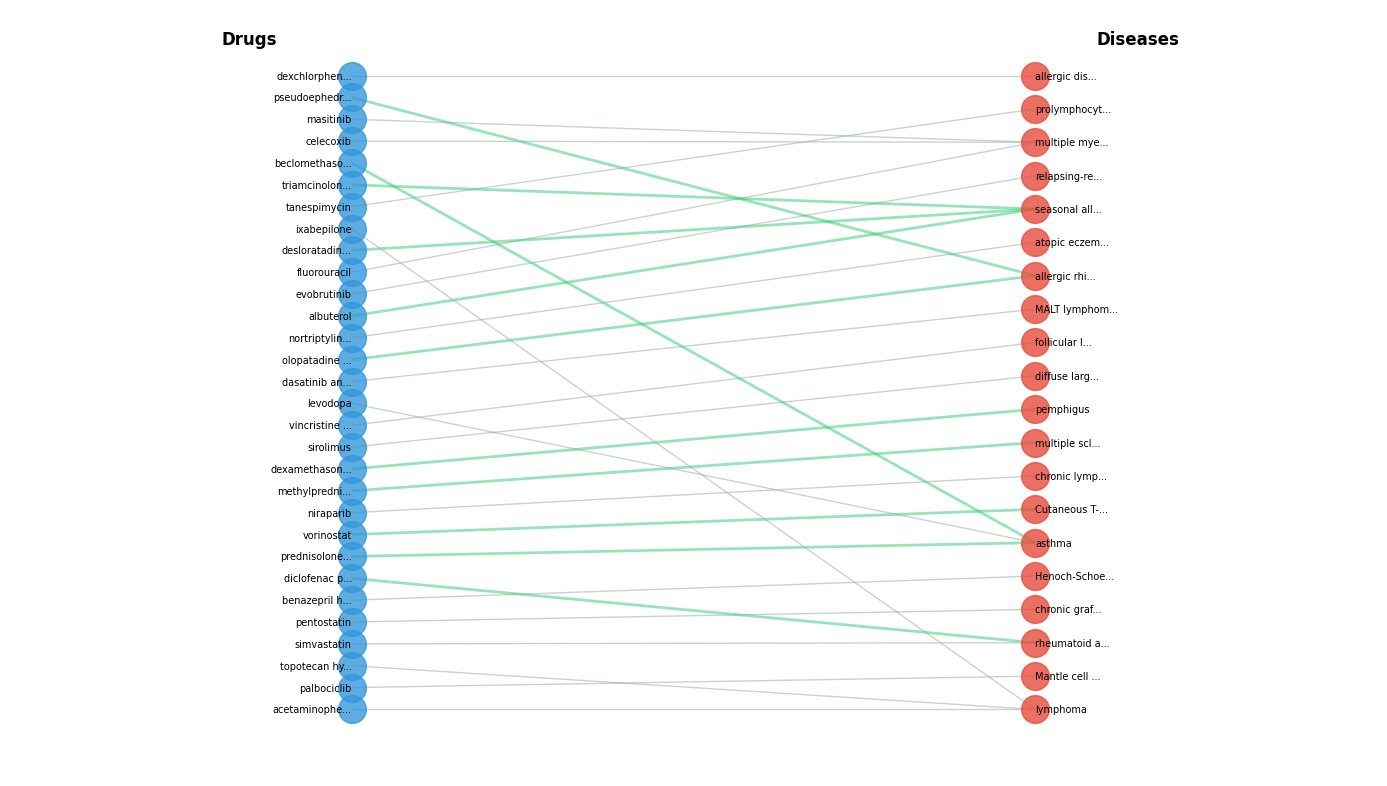

In [15]:
if NX_AVAILABLE:
    # Bipartite layout version
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create bipartite layout
    drug_nodes = [n for n in G.nodes() if G.nodes[n]['node_type'] == 'drug']
    disease_nodes = [n for n in G.nodes() if G.nodes[n]['node_type'] == 'disease']
    
    pos = {}
    for i, drug in enumerate(drug_nodes):
        pos[drug] = (0, i * 2 / max(1, len(drug_nodes)-1) - 1)
    for i, disease in enumerate(disease_nodes):
        pos[disease] = (1, i * 2 / max(1, len(disease_nodes)-1) - 1)
    
    # Draw
    nx.draw_networkx_nodes(G, pos, nodelist=drug_nodes, node_color='#3498db', 
                           node_size=400, alpha=0.8, ax=ax, label='Drugs')
    nx.draw_networkx_nodes(G, pos, nodelist=disease_nodes, node_color='#e74c3c', 
                           node_size=400, alpha=0.8, ax=ax, label='Diseases')
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)
    
    # Labels
    labels_left = {n: n[:12] + '...' if len(n) > 12 else n for n in drug_nodes}
    labels_right = {n: n[:12] + '...' if len(n) > 12 else n for n in disease_nodes}
    
    nx.draw_networkx_labels(G, pos, labels_left, font_size=7, 
                            horizontalalignment='right', ax=ax)
    nx.draw_networkx_labels(G, pos, labels_right, font_size=7, 
                            horizontalalignment='left', ax=ax)
    
    ax.set_xlim(-0.5, 1.5)
    ax.text(-0.15, 1.1, 'Drugs', fontsize=12, fontweight='bold', ha='center')
    ax.text(1.15, 1.1, 'Diseases', fontsize=12, fontweight='bold', ha='center')
    ax.axis('off')
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-bipartite_graph.png", dpi=300, bbox_inches="tight")
    plt.show()

---
## 6. Case Study Examples (Error Analysis)

In [16]:
# Get predictions from best model (XGBoost)
if 'xgb' in models:
    xgb_model = models['xgb']
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    
    # Create results dataframe
    test_results = test_metadata.copy()
    test_results['y_true'] = y_test.values
    test_results['y_pred'] = y_pred
    test_results['y_prob'] = y_prob
    test_results['correct'] = test_results['y_true'] == test_results['y_pred']
    
    # Classify predictions
    test_results['category'] = 'TN'
    test_results.loc[(test_results['y_true'] == True) & (test_results['y_pred'] == True), 'category'] = 'TP'
    test_results.loc[(test_results['y_true'] == False) & (test_results['y_pred'] == True), 'category'] = 'FP'
    test_results.loc[(test_results['y_true'] == True) & (test_results['y_pred'] == False), 'category'] = 'FN'
    
    print("Prediction categories:")
    print(test_results['category'].value_counts())

Prediction categories:
category
TN    79
TP    25
FN    17
FP    13
Name: count, dtype: int64


In [17]:
# Show examples of each category
if 'xgb' in models:
    print("\n=== TRUE POSITIVES (Correctly predicted success) ===")
    tp = test_results[test_results['category'] == 'TP'].nlargest(3, 'y_prob')
    display(tp[['drug_name', 'disease_name', 'y_prob', 'first_trial_date']])
    
    print("\n=== TRUE NEGATIVES (Correctly predicted failure) ===")
    tn = test_results[test_results['category'] == 'TN'].nsmallest(3, 'y_prob')
    display(tn[['drug_name', 'disease_name', 'y_prob', 'first_trial_date']])
    
    print("\n=== FALSE POSITIVES (Predicted success, actually failed) ===")
    fp = test_results[test_results['category'] == 'FP'].nlargest(3, 'y_prob')
    display(fp[['drug_name', 'disease_name', 'y_prob', 'first_trial_date']])
    
    print("\n=== FALSE NEGATIVES (Predicted failure, actually succeeded) ===")
    fn = test_results[test_results['category'] == 'FN'].nsmallest(3, 'y_prob')
    display(fn[['drug_name', 'disease_name', 'y_prob', 'first_trial_date']])


=== TRUE POSITIVES (Correctly predicted success) ===


,drug_name,disease_name,y_prob,first_trial_date
825,epinephrine,seasonal allergic rhinitis,0.994528,2015-06-22
889,fostamatinib,autoimmune thrombocytopenic purpura,0.985201,2019-10-15
842,chlorpheniramine maleate,allergic rhinitis,0.978985,2016-03-23



=== TRUE NEGATIVES (Correctly predicted failure) ===


,drug_name,disease_name,y_prob,first_trial_date
870,midazolam,chronic lymphocytic leukemia,0.004813,2017-09-29
782,dipyridamole,HIV infection,0.005208,2014-04-21
807,mizoribine,lupus nephritis,0.005284,2014-10-01



=== FALSE POSITIVES (Predicted success, actually failed) ===


,drug_name,disease_name,y_prob,first_trial_date
868,halobetasol propionate,atopic eczema,0.977197,2017-07-24
821,flurbiprofen,rheumatoid arthritis,0.946608,2015-05
837,loratadine,asthma,0.915861,2016-01-10



=== FALSE NEGATIVES (Predicted failure, actually succeeded) ===


,drug_name,disease_name,y_prob,first_trial_date
867,bilastine,allergic conjunctivitis,0.013752,2017-07-20
881,dapagliflozin,IGA glomerulonephritis,0.017307,2018-11-27
876,amantadine hydrochloride,multiple sclerosis,0.042780,2018-02-12


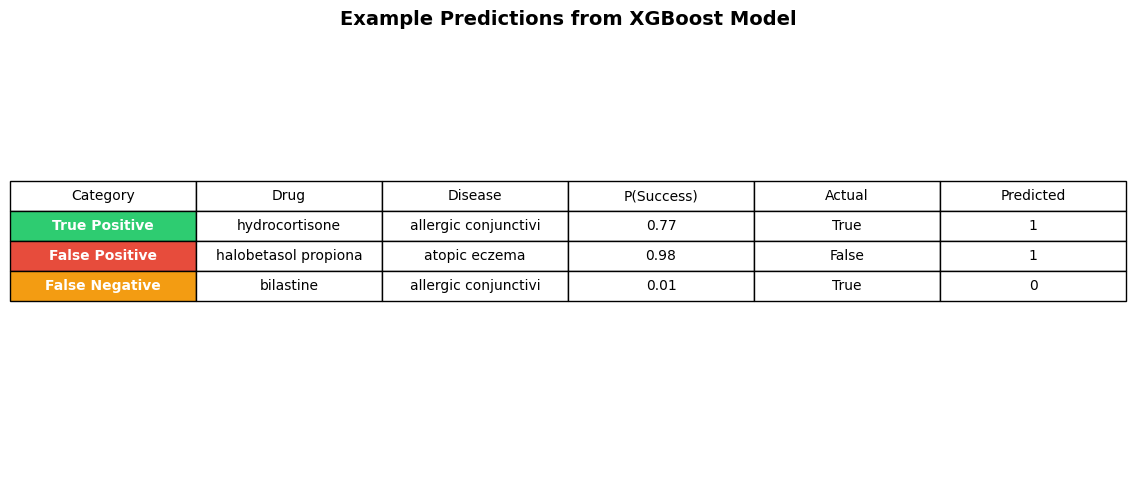

In [18]:
# Create a visual summary table
if 'xgb' in models:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    
    # Prepare data for table
    case_data = []
    for cat, color, label in [('TP', '#2ecc71', 'True Positive'), 
                               ('FP', '#e74c3c', 'False Positive'),
                               ('FN', '#f39c12', 'False Negative')]:
        subset = test_results[test_results['category'] == cat]
        if len(subset) > 0:
            if cat == 'FP':
                example = subset.nlargest(1, 'y_prob').iloc[0]
            else:
                example = subset.iloc[0] if cat == 'TP' else subset.nsmallest(1, 'y_prob').iloc[0]
            case_data.append([
                label,
                example['drug_name'][:20],
                example['disease_name'][:20],
                f"{example['y_prob']:.2f}",
                str(example['y_true']),
                str(example['y_pred'])
            ])
    
    table = ax.table(
        cellText=case_data,
        colLabels=['Category', 'Drug', 'Disease', 'P(Success)', 'Actual', 'Predicted'],
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.8)
    
    # Color the category column
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    for i, color in enumerate(colors[:len(case_data)]):
        table[(i+1, 0)].set_facecolor(color)
        table[(i+1, 0)].set_text_props(color='white', fontweight='bold')
    
    plt.title("Example Predictions from XGBoost Model", fontsize=14, fontweight='bold', y=0.95)
    
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-case_studies_table.png", dpi=300, bbox_inches="tight")
    plt.show()

---
## 7. t-SNE/UMAP Colored by Prediction Correctness

In [19]:
if 'xgb' in models:
    # Use preprocessed test data
    preprocessor = models['xgb'].named_steps['preprocess']
    X_test_scaled = preprocessor.transform(X_test)
    
    # t-SNE
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_test_scaled)
    print("Done!")

Running t-SNE...
Done!


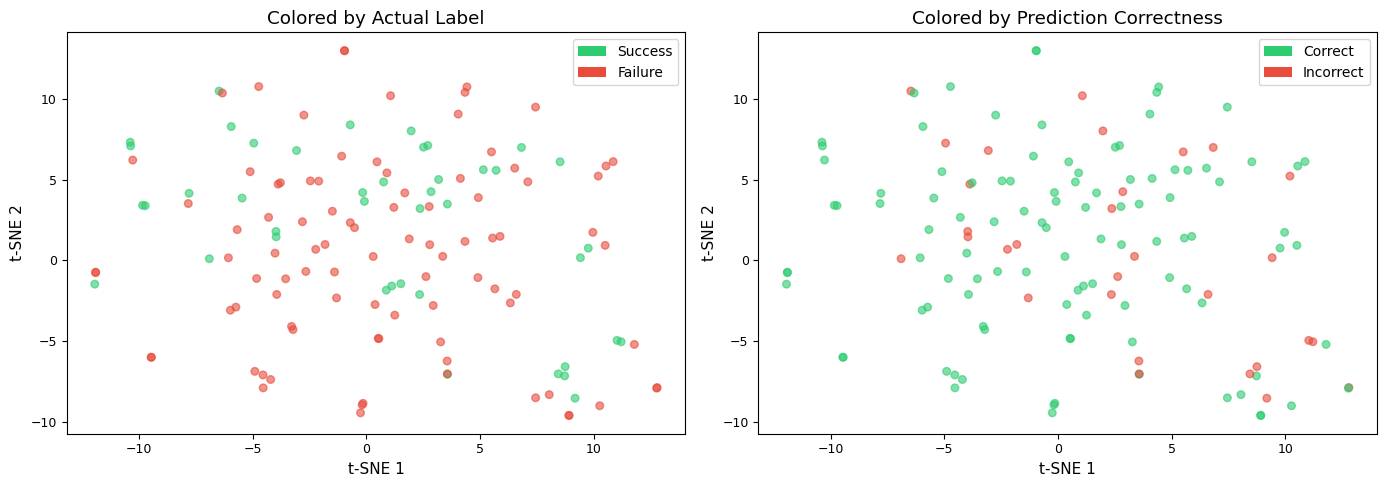

In [20]:
if 'xgb' in models:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Colored by actual label
    ax = axes[0]
    colors = ['#e74c3c' if not y else '#2ecc71' for y in y_test]
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6, s=30)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('Colored by Actual Label')
    legend_elements = [Patch(facecolor='#2ecc71', label='Success'),
                       Patch(facecolor='#e74c3c', label='Failure')]
    ax.legend(handles=legend_elements)
    
    # Plot 2: Colored by prediction correctness
    ax = axes[1]
    colors = ['#2ecc71' if c else '#e74c3c' for c in test_results['correct']]
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.6, s=30)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.set_title('Colored by Prediction Correctness')
    legend_elements = [Patch(facecolor='#2ecc71', label='Correct'),
                       Patch(facecolor='#e74c3c', label='Incorrect')]
    ax.legend(handles=legend_elements)
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-tsne_by_correctness.png", dpi=300, bbox_inches="tight")
    plt.show()

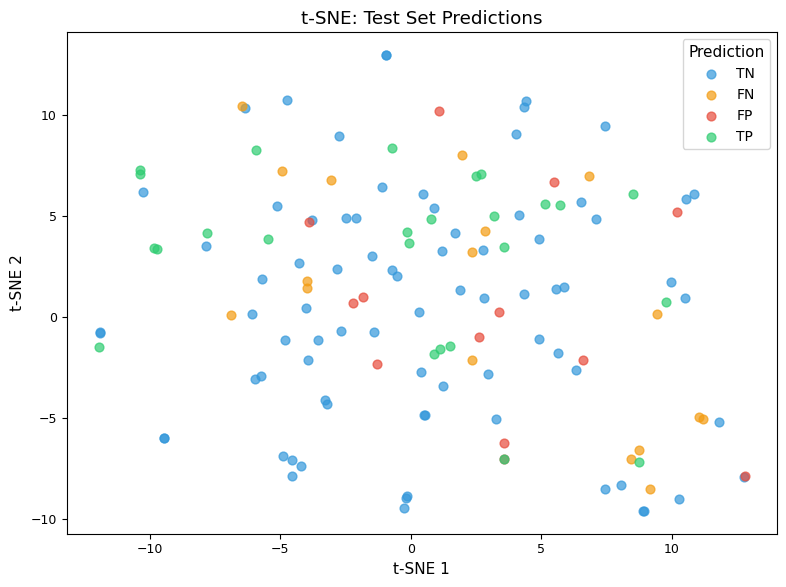

In [21]:
if 'xgb' in models:
    # Plot colored by TP/TN/FP/FN
    fig, ax = plt.subplots(figsize=(8, 6))
    
    category_colors = {'TP': '#2ecc71', 'TN': '#3498db', 'FP': '#e74c3c', 'FN': '#f39c12'}
    
    for cat in ['TN', 'FN', 'FP', 'TP']:  # Order so TP/FP are on top
        mask = test_results['category'] == cat
        ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
                   c=category_colors[cat], label=cat, alpha=0.7, s=40)
    
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(title='Prediction')
    ax.set_title('t-SNE: Test Set Predictions')
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-tsne_by_category.png", dpi=300, bbox_inches="tight")
    plt.show()

---
## 8. Key Numbers Summary (Infographic-style)

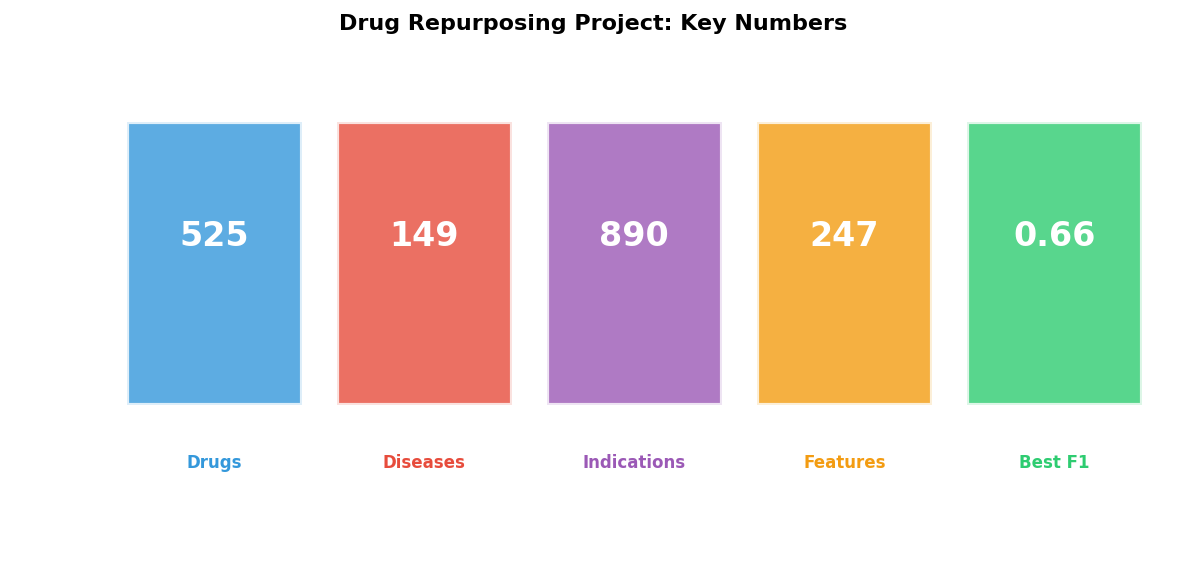

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Key statistics
stats = [
    (f"{len(drugs_df)}", "Drugs", "#3498db"),
    (f"{len(diseases_df)}", "Diseases", "#e74c3c"),
    (f"{len(merged_df)}", "Indications", "#9b59b6"),
    (f"{X.shape[1]}", "Features", "#f39c12"),
    (f"{results_df['F1'].max():.2f}", "Best F1", "#2ecc71"),
]

# Draw boxes
for i, (value, label, color) in enumerate(stats):
    x = 0.1 + i * 0.18
    
    # Box
    rect = plt.Rectangle((x, 0.3), 0.15, 0.5, facecolor=color, alpha=0.8, 
                          edgecolor='white', linewidth=3)
    ax.add_patch(rect)
    
    # Value
    ax.text(x + 0.075, 0.6, value, ha='center', va='center', 
            fontsize=24, fontweight='bold', color='white')
    
    # Label
    ax.text(x + 0.075, 0.2, label, ha='center', va='center', 
            fontsize=12, fontweight='bold', color=color)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Drug Repurposing Project: Key Numbers", fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-key_numbers.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Summary of Generated Figures

| Figure | File | Description |
|--------|------|-------------|
| Model Comparison | `06-model_comparison_bar.png` | Bar chart of F1/Precision/Recall |
| CV F1 Comparison | `06-cv_f1_comparison.png` | Horizontal bar of CV scores |
| Class Imbalance | `06-class_imbalance.png` | Bar + pie chart |
| Temporal Split | `06-temporal_split.png` | Histogram of dates |
| Temporal Timeline | `06-temporal_split_timeline.png` | Simple timeline |
| SHAP Summary | `06-shap_summary.png` | Beeswarm plot |
| SHAP Importance | `06-shap_importance_bar.png` | Bar chart |
| SHAP Dependence | `06-shap_dependence.png` | Top features |
| Network Graph | `06-network_graph.png` | Spring layout |
| Bipartite Graph | `06-bipartite_graph.png` | Bipartite layout |
| Case Studies | `06-case_studies_table.png` | Example predictions |
| t-SNE Correctness | `06-tsne_by_correctness.png` | Error visualization |
| t-SNE Categories | `06-tsne_by_category.png` | TP/TN/FP/FN |
| Key Numbers | `06-key_numbers.png` | Infographic summary |

---
## 9. Learning Curve (Performance vs Training Size)

In [26]:
from sklearn.model_selection import learning_curve
from xgboost import XGBClassifier

# Learning curve for XGBoost
print("Computing learning curve (this may take a few minutes)...")

# Use the XGBoost model with same hyperparameters
xgb_pipeline = models['xgb']
xgb_params = xgb_pipeline.named_steps['xgb'].get_params()

# Create a fresh pipeline for learning curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
preprocessor_lc = ColumnTransformer([("scaler", StandardScaler(), num_cols)], remainder="passthrough")
xgb_lc = XGBClassifier(**{k: v for k, v in xgb_params.items() if k != 'n_jobs'}, n_jobs=-1, verbosity=0)
pipeline_lc = Pipeline([("preprocess", preprocessor_lc), ("xgb", xgb_lc)])

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_lc, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='f1', n_jobs=-1
)

print("Done!")

Computing learning curve (this may take a few minutes)...


TypeError: xgboost.sklearn.XGBClassifier() got multiple values for keyword argument 'verbosity'

NameError: name 'train_scores' is not defined

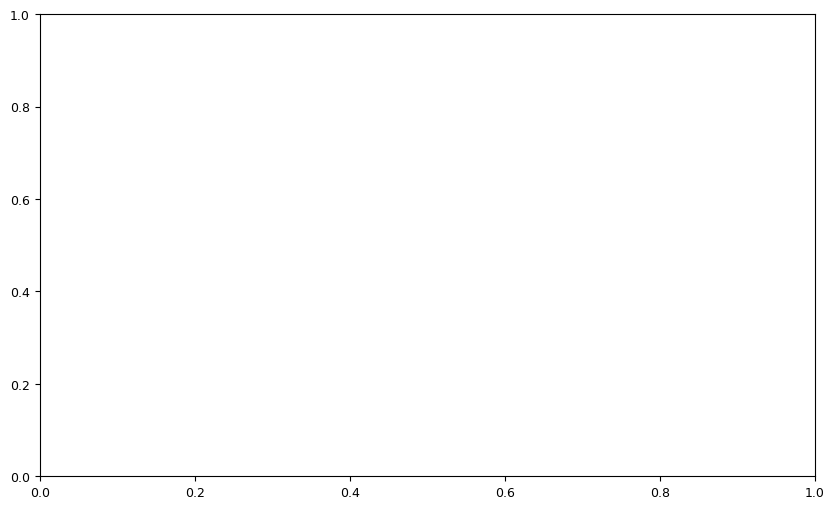

In [27]:
# Plot learning curve
fig, ax = plt.subplots(figsize=(10, 6))

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#3498db')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#e74c3c')

ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training F1', linewidth=2)
ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation F1', linewidth=2)

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.set_title('Learning Curve: XGBoost')
ax.legend(loc='lower right')
ax.set_ylim(0.4, 1.0)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add annotations
ax.annotate(f'Final: {val_mean[-1]:.3f}', 
            xy=(train_sizes[-1], val_mean[-1]),
            xytext=(train_sizes[-1] - 100, val_mean[-1] + 0.05),
            fontsize=10, ha='right',
            arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-learning_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Training F1 at max size: {train_mean[-1]:.3f} ± {train_std[-1]:.3f}")
print(f"Validation F1 at max size: {val_mean[-1]:.3f} ± {val_std[-1]:.3f}")

---
## 10. Threshold Tuning (Precision-Recall Tradeoff)

In [28]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Get probabilities from XGBoost
y_prob = models['xgb'].predict_proba(X_test)[:, 1]

# Compute precision-recall at different thresholds
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_prob)

# Compute F1 scores at different thresholds
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_threshold_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold: Precision={precisions[best_threshold_idx]:.3f}, Recall={recalls[best_threshold_idx]:.3f}, F1={f1_scores[best_threshold_idx]:.3f}")

Best threshold: 0.346
At this threshold: Precision=0.638, Recall=0.714, F1=0.674


/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_64372/2803990460.py:32: RuntimeWarning: divide by zero encountered in divide
  y = f1 * x / (2 * x - f1)


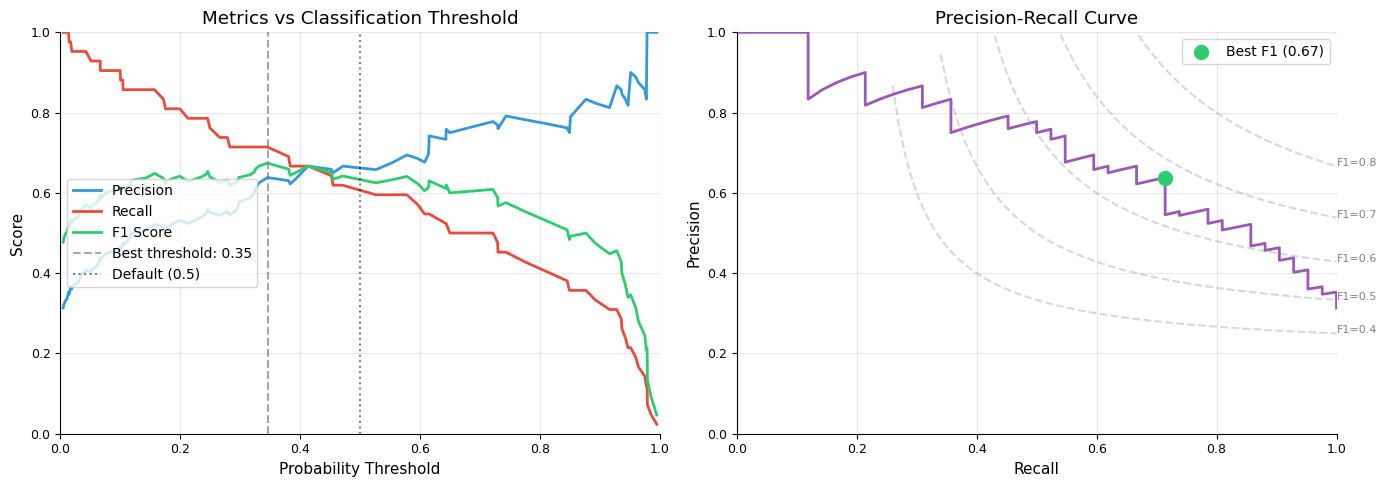

In [29]:
# Plot threshold tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Precision, Recall, F1 vs Threshold
ax = axes[0]
ax.plot(thresholds_pr, precisions[:-1], label='Precision', color='#3498db', linewidth=2)
ax.plot(thresholds_pr, recalls[:-1], label='Recall', color='#e74c3c', linewidth=2)
ax.plot(thresholds_pr, f1_scores, label='F1 Score', color='#2ecc71', linewidth=2)

ax.axvline(x=best_threshold, color='gray', linestyle='--', alpha=0.7, label=f'Best threshold: {best_threshold:.2f}')
ax.axvline(x=0.5, color='black', linestyle=':', alpha=0.5, label='Default (0.5)')

ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Classification Threshold')
ax.legend(loc='center left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot 2: Precision-Recall Curve
ax = axes[1]
ax.plot(recalls, precisions, color='#9b59b6', linewidth=2)
ax.scatter([recalls[best_threshold_idx]], [precisions[best_threshold_idx]], 
           color='#2ecc71', s=100, zorder=5, label=f'Best F1 ({f1_scores[best_threshold_idx]:.2f})')

# Add iso-F1 curves
for f1 in [0.4, 0.5, 0.6, 0.7, 0.8]:
    x = np.linspace(0.01, 1, 100)
    y = f1 * x / (2 * x - f1)
    valid = (y > 0) & (y <= 1)
    ax.plot(x[valid], y[valid], '--', color='gray', alpha=0.3)
    if np.any(valid):
        ax.annotate(f'F1={f1}', xy=(x[valid][-1], y[valid][-1]), fontsize=8, color='gray')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend(loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-threshold_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 11. Feature Correlation with Outcome (Univariate Analysis)

In [30]:
from scipy.stats import pointbiserialr

# Compute point-biserial correlation between each feature and the outcome
correlations = []
for col in X.columns:
    try:
        corr, pval = pointbiserialr(y, X[col])
        correlations.append({
            'feature': col,
            'correlation': corr,
            'p_value': pval,
            'abs_correlation': abs(corr)
        })
    except Exception:
        pass

corr_df = pd.DataFrame(correlations).sort_values('abs_correlation', ascending=False)

print("Top 15 features by correlation with success:")
display(corr_df.head(15)[['feature', 'correlation', 'p_value']])

KeyError: 'abs_correlation'

In [31]:
# Plot top feature correlations
top_n = 20
top_corr = corr_df.head(top_n).copy()
top_corr = top_corr.sort_values('correlation')

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_corr['correlation']]
bars = ax.barh(range(len(top_corr)), top_corr['correlation'], color=colors, alpha=0.8)

ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr['feature'], fontsize=9)
ax.set_xlabel('Point-Biserial Correlation with Success')
ax.set_title(f'Top {top_n} Features by Correlation with Outcome')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add significance markers
for i, (_, row) in enumerate(top_corr.iterrows()):
    if row['p_value'] < 0.001:
        marker = '***'
    elif row['p_value'] < 0.01:
        marker = '**'
    elif row['p_value'] < 0.05:
        marker = '*'
    else:
        marker = ''
    if marker:
        x_pos = row['correlation'] + 0.01 if row['correlation'] > 0 else row['correlation'] - 0.02
        ax.text(x_pos, i, marker, va='center', fontsize=10, color='gray')

# Legend for significance
ax.text(0.95, 0.02, '* p<0.05  ** p<0.01  *** p<0.001', 
        transform=ax.transAxes, fontsize=8, ha='right', color='gray')

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-feature_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'corr_df' is not defined

---
## 12. Model Uncertainty Distribution (Prediction Confidence)

/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_64372/115591300.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([confidence[correct], confidence[~correct]],


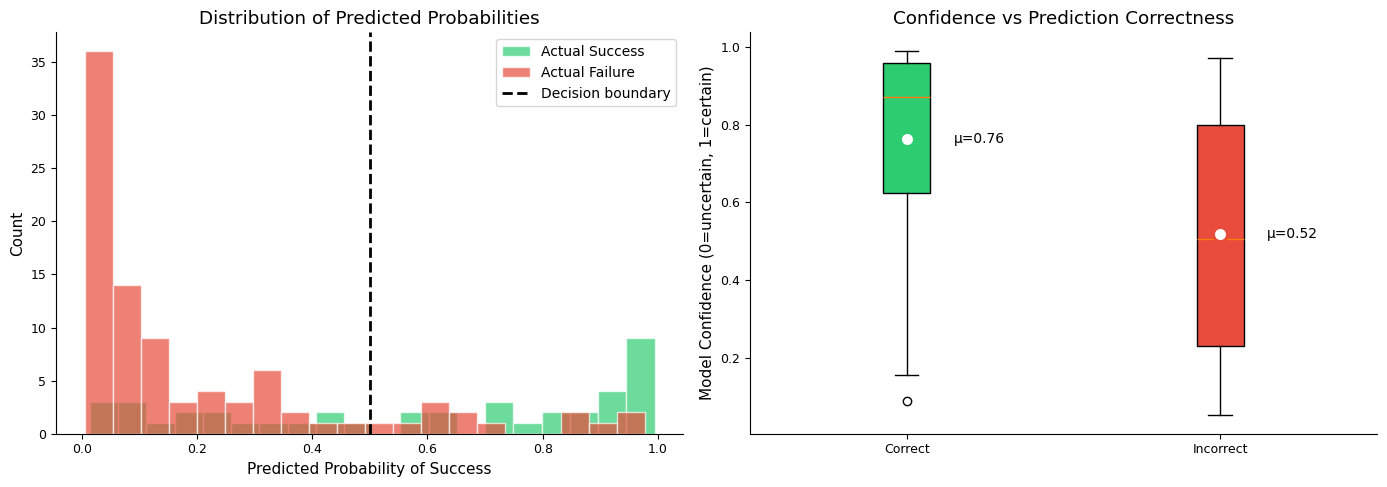

Mean confidence for correct predictions: 0.763
Mean confidence for incorrect predictions: 0.518


In [32]:
# Model uncertainty / confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of predicted probabilities
ax = axes[0]
ax.hist(y_prob[y_test == True], bins=20, alpha=0.7, label='Actual Success', color='#2ecc71', edgecolor='white')
ax.hist(y_prob[y_test == False], bins=20, alpha=0.7, label='Actual Failure', color='#e74c3c', edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
ax.set_xlabel('Predicted Probability of Success')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Probabilities')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Plot 2: Confidence (distance from 0.5) vs Correctness
ax = axes[1]
confidence = np.abs(y_prob - 0.5) * 2  # Scale to 0-1
correct = (y_pred == y_test.values)

# Box plot
bp = ax.boxplot([confidence[correct], confidence[~correct]], 
                labels=['Correct', 'Incorrect'],
                patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')

ax.set_ylabel('Model Confidence (0=uncertain, 1=certain)')
ax.set_title('Confidence vs Prediction Correctness')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add mean values
for i, (data, color) in enumerate([(confidence[correct], '#2ecc71'), (confidence[~correct], '#e74c3c')]):
    ax.scatter([i+1], [data.mean()], color='white', edgecolor=color, s=100, zorder=5, linewidth=2)
    ax.text(i+1.15, data.mean(), f'μ={data.mean():.2f}', va='center', fontsize=10)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-uncertainty_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean confidence for correct predictions: {confidence[correct].mean():.3f}")
print(f"Mean confidence for incorrect predictions: {confidence[~correct].mean():.3f}")

---
## 13. SHAP Waterfall Plot (Single Prediction Explanation)

In [33]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Create SHAP Explanation object for waterfall plot
    # Pick interesting examples: one TP, one FP, one FN
    
    # Find example indices in X_test
    tp_idx = test_results[test_results['category'] == 'TP'].nlargest(1, 'y_prob').index[0]
    fp_idx = test_results[test_results['category'] == 'FP'].nlargest(1, 'y_prob').index[0]
    fn_idx = test_results[test_results['category'] == 'FN'].nsmallest(1, 'y_prob').index[0]
    
    # Get relative positions in X_test
    test_indices = X_test.index.tolist()
    tp_pos = test_indices.index(tp_idx)
    fp_pos = test_indices.index(fp_idx)
    fn_pos = test_indices.index(fn_idx)
    
    print(f"Selected examples:")
    print(f"  TP: {test_results.loc[tp_idx, 'drug_name']} - {test_results.loc[tp_idx, 'disease_name']} (prob={test_results.loc[tp_idx, 'y_prob']:.2f})")
    print(f"  FP: {test_results.loc[fp_idx, 'drug_name']} - {test_results.loc[fp_idx, 'disease_name']} (prob={test_results.loc[fp_idx, 'y_prob']:.2f})")
    print(f"  FN: {test_results.loc[fn_idx, 'drug_name']} - {test_results.loc[fn_idx, 'disease_name']} (prob={test_results.loc[fn_idx, 'y_prob']:.2f})")

Selected examples:
  TP: epinephrine - seasonal allergic rhinitis (prob=0.99)
  FP: halobetasol propionate - atopic eczema (prob=0.98)
  FN: bilastine - allergic conjunctivitis (prob=0.01)


IndexError: string index out of range

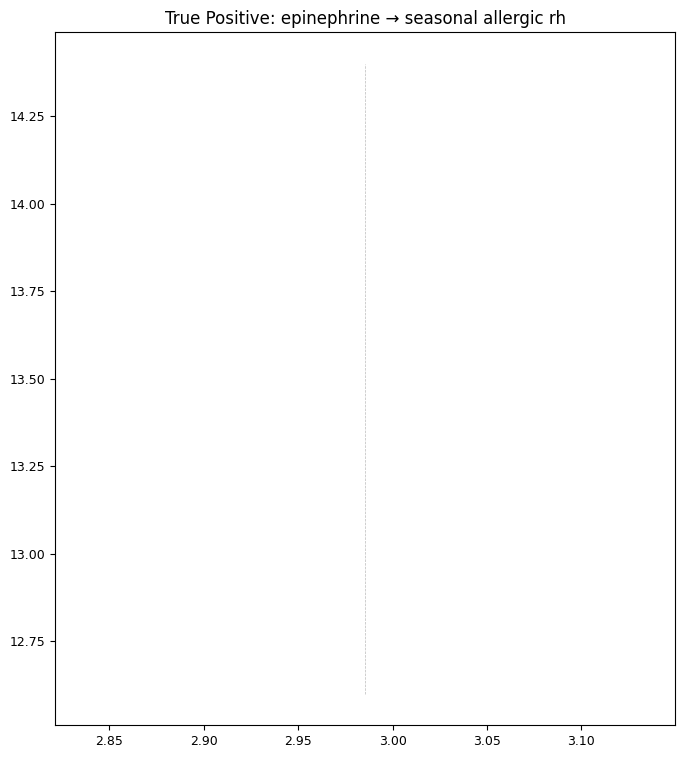

In [34]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Create SHAP Explanation object
    shap_explanation = shap.Explanation(
        values=shap_values,
        base_values=explainer.expected_value,
        data=X_test_transformed,
        feature_names=feature_names
    )
    
    # Plot waterfall for True Positive
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.title(f"True Positive: {test_results.loc[tp_idx, 'drug_name'][:20]} → {test_results.loc[tp_idx, 'disease_name'][:20]}", fontsize=12)
    shap.plots.waterfall(shap_explanation[tp_pos], max_display=15, show=False)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_waterfall_tp.png", dpi=300, bbox_inches="tight")
    plt.show()

In [35]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Plot waterfall for False Positive (model was wrong - predicted success, actually failed)
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.title(f"False Positive: {test_results.loc[fp_idx, 'drug_name'][:20]} → {test_results.loc[fp_idx, 'disease_name'][:20]}", fontsize=12)
    shap.plots.waterfall(shap_explanation[fp_pos], max_display=15, show=False)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_waterfall_fp.png", dpi=300, bbox_inches="tight")
    plt.show()

IndexError: string index out of range

In [ ]:
if SHAP_AVAILABLE and 'xgb' in models:
    # Plot waterfall for False Negative (model was wrong - predicted failure, actually succeeded)
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.title(f"False Negative: {test_results.loc[fn_idx, 'drug_name'][:20]} → {test_results.loc[fn_idx, 'disease_name'][:20]}", fontsize=12)
    shap.plots.waterfall(shap_explanation[fn_pos], max_display=15, show=False)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-shap_waterfall_fn.png", dpi=300, bbox_inches="tight")
    plt.show()

---
## 14. Case Study Deep-Dive (Detailed Analysis)

In [36]:
# Detailed case study: Compare a True Positive vs False Positive
# This helps understand what the model learned vs where it fails

# Select compelling examples
tp_example = test_results[test_results['category'] == 'TP'].nlargest(1, 'y_prob').iloc[0]
fp_example = test_results[test_results['category'] == 'FP'].nlargest(1, 'y_prob').iloc[0]
fn_example = test_results[test_results['category'] == 'FN'].nsmallest(1, 'y_prob').iloc[0]

print("=" * 80)
print("CASE STUDY: UNDERSTANDING MODEL PREDICTIONS")
print("=" * 80)

for label, example, color in [
    ("TRUE POSITIVE ✓", tp_example, "\033[92m"),
    ("FALSE POSITIVE ✗", fp_example, "\033[91m"),
    ("FALSE NEGATIVE ✗", fn_example, "\033[93m")
]:
    print(f"\n{color}{label}\033[0m")
    print(f"  Drug: {example['drug_name']}")
    print(f"  Disease: {example['disease_name']}")
    print(f"  Predicted probability: {example['y_prob']:.3f}")
    print(f"  Actual outcome: {'Success' if example['y_true'] else 'Failure'}")
    print(f"  Trial date: {example['first_trial_date']}")

CASE STUDY: UNDERSTANDING MODEL PREDICTIONS

TRUE POSITIVE ✓
  Drug: epinephrine
  Disease: seasonal allergic rhinitis
  Predicted probability: 0.995
  Actual outcome: Success
  Trial date: 2015-06-22

FALSE POSITIVE ✗
  Drug: halobetasol propionate
  Disease: atopic eczema
  Predicted probability: 0.977
  Actual outcome: Failure
  Trial date: 2017-07-24

FALSE NEGATIVE ✗
  Drug: bilastine
  Disease: allergic conjunctivitis
  Predicted probability: 0.014
  Actual outcome: Success
  Trial date: 2017-07-20


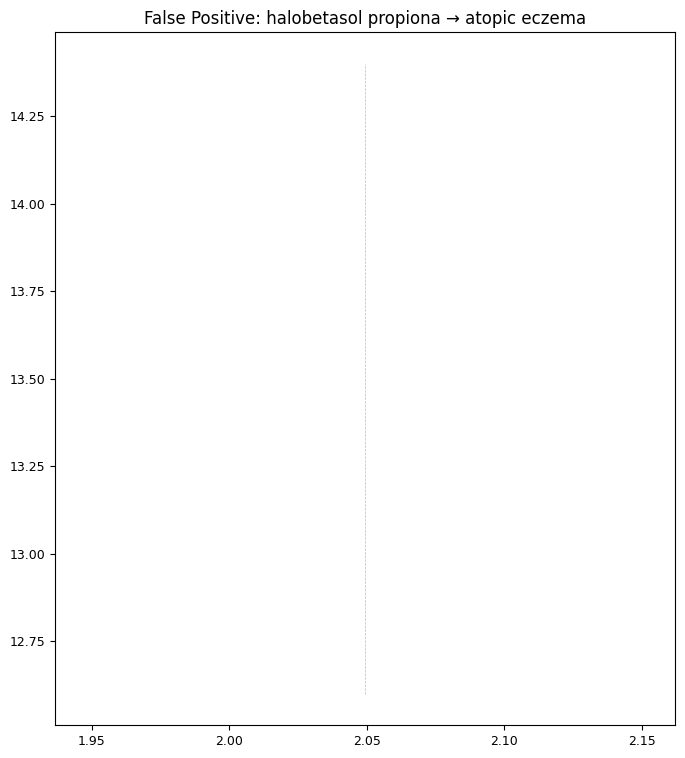

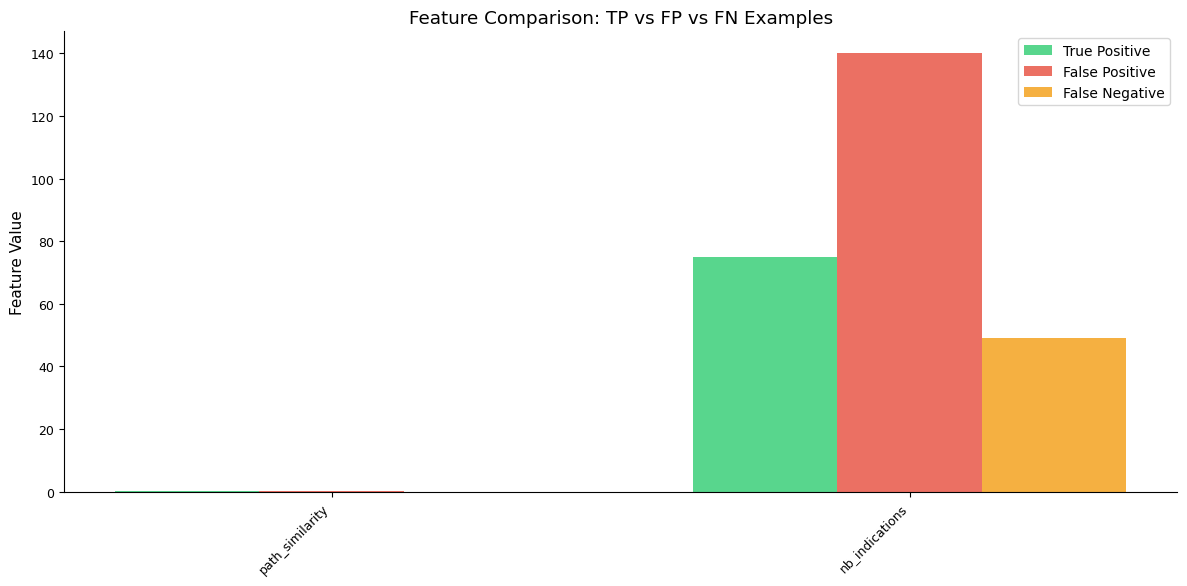

In [37]:
# Visual comparison of features for TP vs FP vs FN
# Get the feature values for these examples
tp_features = X.loc[tp_example.name]
fp_features = X.loc[fp_example.name]
fn_features = X.loc[fn_example.name]

# Select interpretable features to compare
interpretable_features = ['path_similarity', 'nb_indications', 'HeavyAtomCount', 
                          'NumHAcceptors', 'NumHDonors', 'MolLogP', 'TPSA']
available_features = [f for f in interpretable_features if f in X.columns]

if len(available_features) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(len(available_features))
    width = 0.25
    
    # Normalize values for comparison
    tp_vals = [tp_features[f] for f in available_features]
    fp_vals = [fp_features[f] for f in available_features]
    fn_vals = [fn_features[f] for f in available_features]
    
    # Create bars
    ax.bar(x - width, tp_vals, width, label='True Positive', color='#2ecc71', alpha=0.8)
    ax.bar(x, fp_vals, width, label='False Positive', color='#e74c3c', alpha=0.8)
    ax.bar(x + width, fn_vals, width, label='False Negative', color='#f39c12', alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(available_features, rotation=45, ha='right')
    ax.set_ylabel('Feature Value')
    ax.set_title('Feature Comparison: TP vs FP vs FN Examples')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(FIG_PATH + "06-case_study_features.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Could not find interpretable features for comparison")

/var/folders/82/l2yr6j1x62g7c13jgxw81s3c0000gn/T/ipykernel_64372/3956828555.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


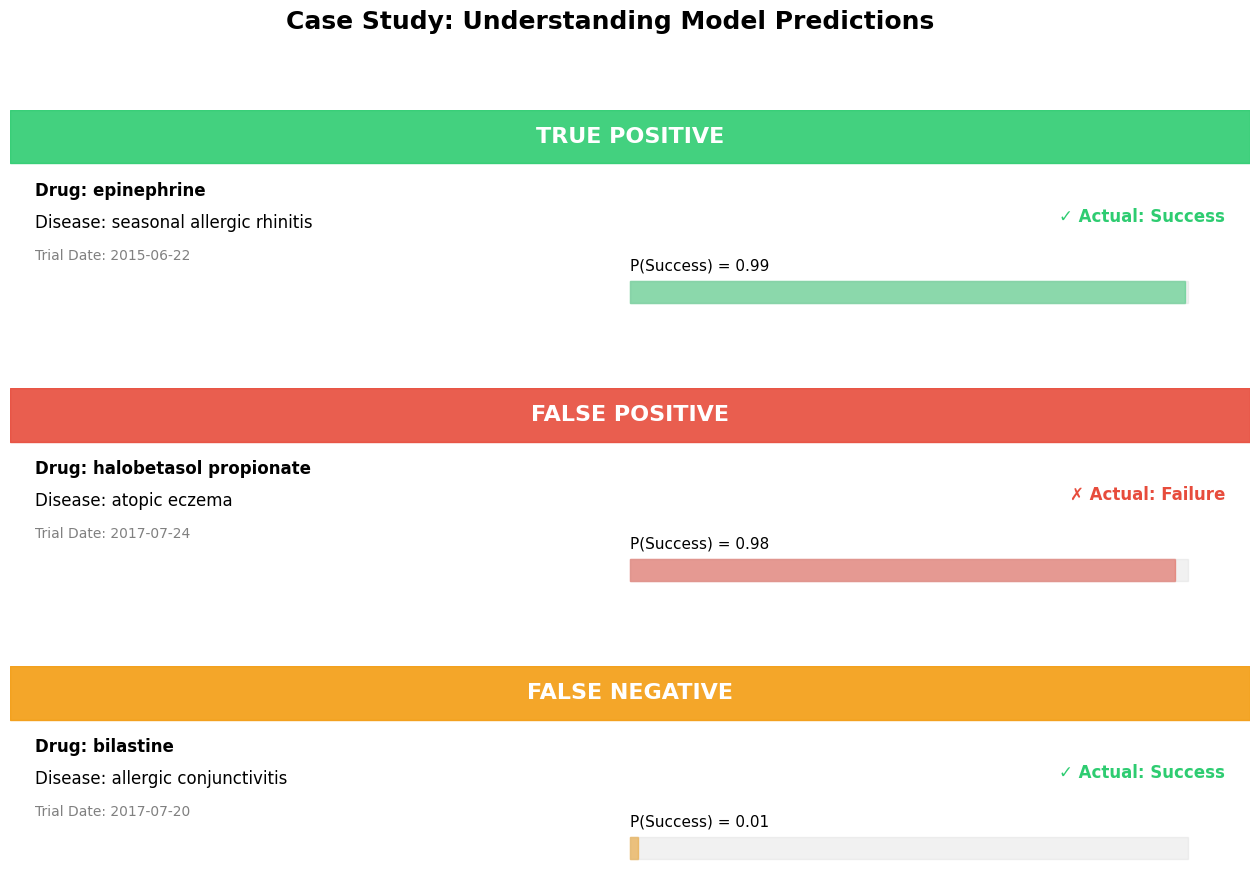

In [38]:
# Create a summary card for presentation
fig = plt.figure(figsize=(16, 10))

# Create grid
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

cases = [
    ("TRUE POSITIVE", tp_example, '#2ecc71', 'Correctly predicted success'),
    ("FALSE POSITIVE", fp_example, '#e74c3c', 'Wrongly predicted success'),
    ("FALSE NEGATIVE", fn_example, '#f39c12', 'Missed a success')
]

for i, (title, example, color, description) in enumerate(cases):
    ax = fig.add_subplot(gs[i, :])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Title bar
    ax.axhspan(0.75, 1.0, color=color, alpha=0.9)
    ax.text(0.5, 0.875, title, ha='center', va='center', fontsize=16, fontweight='bold', color='white')
    
    # Content
    ax.text(0.02, 0.6, f"Drug: {example['drug_name']}", fontsize=12, fontweight='bold')
    ax.text(0.02, 0.45, f"Disease: {example['disease_name']}", fontsize=12)
    ax.text(0.02, 0.3, f"Trial Date: {example['first_trial_date']}", fontsize=10, color='gray')
    
    # Probability bar
    prob = example['y_prob']
    ax.axhspan(0.1, 0.2, xmin=0.5, xmax=0.5 + prob * 0.45, color=color, alpha=0.7)
    ax.axhspan(0.1, 0.2, xmin=0.5, xmax=0.95, color='lightgray', alpha=0.3)
    ax.text(0.5, 0.25, f"P(Success) = {prob:.2f}", fontsize=11)
    
    # Actual outcome
    outcome = "✓ Actual: Success" if example['y_true'] else "✗ Actual: Failure"
    outcome_color = '#2ecc71' if example['y_true'] else '#e74c3c'
    ax.text(0.98, 0.5, outcome, ha='right', va='center', fontsize=12, color=outcome_color, fontweight='bold')

plt.suptitle("Case Study: Understanding Model Predictions", fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(FIG_PATH + "06-case_study_cards.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Updated Summary of Generated Figures

| # | Figure | File | Description |
|---|--------|------|-------------|
| 1 | Model Comparison | `06-model_comparison_bar.png` | Bar chart of F1/Precision/Recall |
| 2 | CV F1 Comparison | `06-cv_f1_comparison.png` | Horizontal bar of CV scores |
| 3 | Class Imbalance | `06-class_imbalance.png` | Bar + pie chart |
| 4 | Temporal Split | `06-temporal_split.png` | Histogram of dates |
| 5 | Temporal Timeline | `06-temporal_split_timeline.png` | Simple timeline |
| 6 | SHAP Summary | `06-shap_summary.png` | Beeswarm plot |
| 7 | SHAP Importance | `06-shap_importance_bar.png` | Bar chart |
| 8 | SHAP Dependence | `06-shap_dependence.png` | Top features |
| 9 | Network Graph | `06-network_graph.png` | Spring layout |
| 10 | Bipartite Graph | `06-bipartite_graph.png` | Bipartite layout |
| 11 | Case Studies Table | `06-case_studies_table.png` | Example predictions |
| 12 | t-SNE Correctness | `06-tsne_by_correctness.png` | Error visualization |
| 13 | t-SNE Categories | `06-tsne_by_category.png` | TP/TN/FP/FN |
| 14 | Key Numbers | `06-key_numbers.png` | Infographic summary |
| **15** | **Learning Curve** | `06-learning_curve.png` | Performance vs training size |
| **16** | **Threshold Tuning** | `06-threshold_tuning.png` | Precision-recall tradeoff |
| **17** | **Feature Correlation** | `06-feature_correlation.png` | Univariate correlations |
| **18** | **Uncertainty Distribution** | `06-uncertainty_distribution.png` | Confidence histogram |
| **19** | **SHAP Waterfall (TP)** | `06-shap_waterfall_tp.png` | Single prediction explanation |
| **20** | **SHAP Waterfall (FP)** | `06-shap_waterfall_fp.png` | Why model was wrong |
| **21** | **SHAP Waterfall (FN)** | `06-shap_waterfall_fn.png` | Missed success explanation |
| **22** | **Case Study Features** | `06-case_study_features.png` | Feature comparison |
| **23** | **Case Study Cards** | `06-case_study_cards.png` | Visual summary cards |